<a href="https://colab.research.google.com/github/youma-code/qqq/blob/main/1.2.5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import time

# ======================
# データ取得
# ======================
ticker = "AAPL"
start_date = "2020-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")

def download_data(ticker, start, end):
    for _ in range(5):
        df = yf.download(ticker, start=start, end=end)
        if not df.empty:
            return df
        time.sleep(3)
    return pd.DataFrame()

df = download_data(ticker, start_date, end_date)

# ======================
# 整形
# ======================
if isinstance(df.columns, pd.MultiIndex):
    df = df[['Close', 'High', 'Low', 'Volume']].droplevel(1, axis=1)
else:
    df = df[['Close', 'High', 'Low', 'Volume']].copy()

df.columns = ['Close', 'High', 'Low', 'Volume']
df.dropna(inplace=True)

# ======================
# 特徴量作成（強化版）
# ======================

# --- SMA系 ---
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_25"] = df["Close"].rolling(25).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()
df["SMA_DIFF"] = df["SMA_5"] - df["SMA_25"]
df["SMA_RATIO"] = df["SMA_5"] / (df["SMA_25"] + 1e-9)

# --- Target ---
future_max = df["Close"].shift(-1).rolling(3).max()
df["Target"] = ((future_max / df["Close"] - 1) > 0.0075).astype(int)

# --- RSI ---
delta = df["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / (loss + 1e-9)
df["RSI"] = 100 - (100 / (1 + rs))

# --- MACD ---
ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()
df["MACD"] = ema12 - ema26
df["Signal_Line"] = df["MACD"].ewm(span=9).mean()
df["MACD_Hist"] = df["MACD"] - df["Signal_Line"]

# --- ボラ・リターン ---
df["Daily_Return"] = df["Close"].pct_change()
df["Volatility_Short"] = df["Daily_Return"].rolling(5).std()

# --- ATR ---
tr = pd.concat([
    df["High"] - df["Low"],
    abs(df["High"] - df["Close"].shift()),
    abs(df["Low"] - df["Close"].shift())
], axis=1).max(axis=1)

df["ATR"] = tr.rolling(14).mean()

# ======================
# 🔥追加強化特徴量
# ======================

# モメンタム
df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

# ボラ構造
df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

# レンジ度
df["RANGE_SCORE"] = abs(df["RSI"] - 50)

# モメンタム補助
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ======================
# cleanup
# ======================
df = df.dropna()

# ======================
# ADX（ここが重要）
# ======================
window = 14

plus_dm = df["High"].diff()
minus_dm = -df["Low"].diff()

plus_dm = plus_dm.clip(lower=0)
minus_dm = minus_dm.clip(lower=0)

tr = pd.concat([
    df["High"] - df["Low"],
    (df["High"] - df["Close"].shift()).abs(),
    (df["Low"] - df["Close"].shift()).abs()
], axis=1).max(axis=1)

atr = tr.rolling(window).mean()

plus_di = 100 * (plus_dm.rolling(window).mean() / (atr + 1e-9))
minus_di = 100 * (minus_dm.rolling(window).mean() / (atr + 1e-9))

dx = (abs(plus_di - minus_di) / (plus_di + minus_di + 1e-9)) * 100

df["ADX"] = dx.rolling(window).mean()

# ======================
# 追加特徴量（ADX後にやる！）
# ======================

df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

df["RANGE_SCORE"] = abs(df["RSI"] - 50)
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ★ここで初めて作る
df["TREND_STRENGTH"] = df["ADX"] * df["MACD_Hist"]

# --- BB ---
ma = df["Close"].rolling(20).mean()
std = df["Close"].rolling(20).std()

df["Upper_BB"] = ma + 2 * std
df["Lower_BB"] = ma - 2 * std
df["BB_Width"] = (df["Upper_BB"] - df["Lower_BB"]) / (ma + 1e-9)

# --- lag ---
for lag in range(1, 6):
    df[f"Close_Lag_{lag}"] = df["Close"].shift(lag)

# ======================
# 🔥新規追加: レジーム分離と正規化ADX、市場レジーム
# ======================
df["ADX_normalized"] = df["ADX"] / 100  # ADXを0-1に正規化
# 初期データ準備ではデフォルトのADX閾値を使用 (Optunaで最適化)
default_adx_regime_threshold = 20
df["trend_regime"] = (df["ADX"] > default_adx_regime_threshold).astype(int)

# --- Market Regime ---
df["Market_Regime"] = "sideways" # Default
df.loc[df["SMA_50"] > df["SMA_200"], "Market_Regime"] = "uptrend"
df.loc[df["SMA_50"] < df["SMA_200"], "Market_Regime"] = "downtrend"

# ======================
# cleanup
# ======================
df.dropna(inplace=True)

print("完了:", df.shape)

/tmp/ipykernel_84081/412454942.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

完了: (1365, 39)


In [2]:
# ======================
# 特徴量リスト（固定）
# ======================

features = [
    'SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO',
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width',
    'Volatility_Short',
    'ADX',
    'ADX_normalized',  # ←追加: 正規化ADX
    'trend_regime',
    'RET_5',
    'TREND_STRENGTH' # Missing feature added here
]
# ラグ特徴量（セル1で作ったやつに対応）
for lag in range(1, 6):
    features.append(f'Close_Lag_{lag}')

# 存在しない列があったら弾く（安全対策）
if 'df' not in globals():
    print("エラー: DataFrame 'df' が定義されていません。このセルを実行する前に、データをロードしてdfを作成する前のセルを実行してください。")
    raise NameError("DataFrame 'df' is not defined. Please run the data preparation cells above.")

# NOTE: Market_Regime will be one-hot encoded later on the full df.
# The encoded columns will be added to the features list dynamically.

features = [f for f in features if f in df.columns]

print("使用特徴量数:", len(features))
print(features[:10])

使用特徴量数: 23
['SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist', 'ATR', 'Upper_BB']


In [3]:
# ======================
# X, y 作成
# ======================

# 念のためチェック
assert 'Target' in df.columns, "Target列が存在しません"

# ① 最初に一度だけ全体データでエンコードする（超重要）
# Market_Regime をワンホットエンコーディング
df_encoded = pd.get_dummies(df, columns=["Market_Regime"], drop_first=True)

# One-hot encodedされたMarket_Regimeの列名を動的に取得
encoded_market_regime_cols = [col for col in df_encoded.columns if col.startswith('Market_Regime_')]

# ② feature_columnsは既存の特徴量とエンコードされたMarket_Regimeの列を結合
final_features = features + encoded_market_regime_cols

# Xとyをこのエンコード済みデータから作る
X = df_encoded[final_features].copy()
y = df_encoded['Target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target分布:")
print(y.value_counts(normalize=True))

X shape: (1365, 24)
y shape: (1365,)
Target分布:
Target
0    0.528938
1    0.471062
Name: proportion, dtype: float64


In [4]:
# This cell is superseded by the logic in cauDYW8ZZ2xR, where X and y are created
# from the one-hot encoded DataFrame (df_encoded) using final_features.
# Leaving this as a placeholder to indicate it's no longer used.
# Original content:
# X = df[features]
# y = df['Target']
# print(f"X and y defined. Feature matrix shape: {X.shape}")

In [5]:
# ======================
# 時系列分割
# ======================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test  = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test  = y.iloc[split_index:].copy()

print("Train期間:", X_train.index.min(), "→", X_train.index.max())
print("Test期間 :", X_test.index.min(), "→", X_test.index.max())

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train期間: 2020-11-23 00:00:00 → 2025-03-31 00:00:00
Test期間 : 2025-04-01 00:00:00 → 2026-05-01 00:00:00
Train size: (1092, 24)
Test size : (273, 24)


In [6]:
# ======================
# SMOTE（訓練データのみ）
# ======================

from imblearn.over_sampling import SMOTE
import pandas as pd # pandasをインポート

smote = SMOTE(random_state=42)

# X_train は既にワンホットエンコーディングされているため、ここでは追加のエンコーディングは不要

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE: Target
0    553
1    539
Name: count, dtype: int64
After SMOTE:
Target
1    553
0    553
Name: count, dtype: int64


In [7]:
# ======================
# RandomForest チューニング
# ======================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# モデル定義
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# パラメータ範囲
param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

# チューニング
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,                # 最初は軽めでOK（後で増やせる）
    scoring='f1',             # 不均衡データ向け
    cv=3,                     # 時系列じゃない簡易CV（後で改善）
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ使う）
random_search_rf.fit(X_train_resampled, y_train_resampled)

# 最適モデル
model_rf_tuned = random_search_rf.best_estimator_

print("Best params:", random_search_rf.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'max_depth': 14, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 230}


In [8]:
# ======================
# XGBoost チューニング
# ======================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# モデル定義
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# パラメータ範囲
param_dist_xgb = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 1.5)
}

# チューニング
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,          # 最初は軽め
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ）
# pandas DataFrame/SeriesをNumPy配列に変換して渡すことでAttributeErrorを回避
random_search_xgb.fit(X_train_resampled.values, y_train_resampled.values)

# 最適モデル
model_xgb_tuned = random_search_xgb.best_estimator_

print("Best params:", random_search_xgb.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'colsample_bytree': np.float64(0.7580600944007257), 'gamma': np.float64(0.4633294328968971), 'learning_rate': np.float64(0.1554543991712842), 'max_depth': 10, 'n_estimators': 314, 'reg_alpha': np.float64(0.26041713001291183), 'reg_lambda': np.float64(1.9417580365240237), 'subsample': np.float64(0.9378135394712606)}


In [9]:
# ======================
# 予測確率の取得
# ======================

# X_test は既にワンホットエンコーディングされているため、ここでは追加のエンコーディングは不要
# X_test_encoded = X_test.copy() # 以前のロジックは不要

# 訓練データとテストデータでカラムの不一致がないように調整のロジックも不要
# X_test_aligned = X_test.copy() # 以前のロジックは不要

# RandomForest
proba_class1_rf = model_rf_tuned.predict_proba(X_test)[:, 1]

# XGBoost
proba_class1_xgb = model_xgb_tuned.predict_proba(X_test.values)[:, 1]

# 確認
print("RF proba shape:", proba_class1_rf.shape)
print("XGB proba shape:", proba_class1_xgb.shape)

RF proba shape: (273,)
XGB proba shape: (273,)


In [10]:
# ======================
# 戦略A・Bの定義
# ======================

# 閾値（あとで調整可能）
threshold = 0.6

# --- 戦略A：AND条件（両モデルが強気） ---
strategy_A = (
    (proba_class1_rf > threshold) &
    (proba_class1_xgb > threshold)
).astype(int)

# --- 戦略B：XGBoost重視 ---
strategy_B = (
    (proba_class1_xgb > threshold)
).astype(int)

# 確認
print("Strategy A trades:", strategy_A.sum())
print("Strategy B trades:", strategy_B.sum())

Strategy A trades: 43
Strategy B trades: 83


In [11]:
import numpy as np
import pandas as pd

def run_backtest(
    df,
    X_test,
    signal_multipliers,
    df_trade_info, # New parameter to pass df_test_slice with entry_score and proba
    initial_balance=100000
):

    # --- テスト期間 ---
    df_bt = df.loc[X_test.index].copy()

    # 必須データチェック
    required_cols = ['Close', 'ATR']
    df_bt = df_bt.dropna(subset=required_cols)

    # signal_multipliers align
    signal_multipliers = signal_multipliers.loc[df_bt.index] # Align multipliers
    df_trade_info = df_trade_info.loc[df_bt.index] # Align df_trade_info

    # --- 初期化 ---
    balance = initial_balance
    equity_curve = []

    position = 0
    entry_price = 0
    entry_atr = 0

    trade_count = 0
    win_count = 0
    trade_pnls = []
    trade_log = [] # New: To store detailed trade information

    # --- 固定リスク管理パラメータ ---
    risk_per_trade = 0.01
    atr_tp_multiplier = 2.5
    atr_sl_multiplier = 1.2

    # ======================
    # メインループ
    # ======================
    for i in range(len(df_bt) - 1):

        row = df_bt.iloc[i]
        next_row = df_bt.iloc[i + 1]

        current_signal_multiplier = signal_multipliers.iloc[i]

        # ======================
        # エントリー
        # ======================
        if position == 0 and current_signal_multiplier > 0:

            atr = row['ATR']
            if pd.isna(atr) or atr == 0:
                equity_curve.append(balance)
                continue

            risk_amount = balance * risk_per_trade
            stop_distance = atr * atr_sl_multiplier

            unit_position_size = risk_amount / stop_distance

            entry_price = next_row['Close']
            entry_atr = atr

            # Capture entry_score and proba at the time of entry
            entry_score_at_trade = df_trade_info.iloc[i]['entry_score']
            proba_at_trade = df_trade_info.iloc[i]['proba']

            # Capture market regime at entry
            market_regime_uptrend_at_trade = df_trade_info.iloc[i].get('Market_Regime_uptrend', 0)
            market_regime_downtrend_at_trade = df_trade_info.iloc[i].get('Market_Regime_downtrend', 0)

            # Determine the market regime string
            if market_regime_uptrend_at_trade == 1:
                current_regime = "uptrend"
            elif market_regime_downtrend_at_trade == 1:
                current_regime = "downtrend"
            else:
                current_regime = "sideways"

            position = unit_position_size * current_signal_multiplier
            trade_count += 1

        # ======================
        # ポジション管理
        # ======================
        elif position > 0:

            current_price = next_row['Close']

            stop_price = entry_price - (entry_atr * atr_sl_multiplier)
            take_profit_price = entry_price + (entry_atr * atr_tp_multiplier)

            exit_flag = False

            if current_price <= stop_price:
                exit_flag = True
            elif current_price >= take_profit_price:
                exit_flag = True

            if exit_flag:

                pnl = (current_price - entry_price) * position
                balance += pnl
                trade_pnls.append(pnl)

                win_flag = pnl > 0
                if win_flag:
                    win_count += 1

                # New: Add detailed trade info to log
                trade_log.append({
                    'pnl': pnl,
                    'win': win_flag,
                    'entry_score': entry_score_at_trade,
                    'proba': proba_at_trade,
                    'market_regime': current_regime # Add this
                })

                position = 0

        # ======================
        # equity
        # ======================
        if position > 0:
            unrealized = (row['Close'] - entry_price) * position
            equity_curve.append(balance + unrealized)
        else:
            equity_curve.append(balance)

    # ======================
    # 強制決済
    # ======================
    if position > 0:

        final_price = df_bt.iloc[-1]['Close']
        pnl = (final_price - entry_price) * position
        balance += pnl
        trade_pnls.append(pnl)

        win_flag = pnl > 0
        if win_flag:
            win_count += 1

        # New: Add detailed trade info to log for the last open trade
        trade_log.append({
            'pnl': pnl,
            'win': win_flag,
            'entry_score': entry_score_at_trade, # Use the entry score from when the trade was opened
            'proba': proba_at_trade,             # Use the proba from when the trade was opened
            'market_regime': current_regime # Add this
        })

        equity_curve[-1] = balance

    # ======================
    # 指標
    # ======================
    win_rate = (win_count / trade_count * 100) if trade_count > 0 else 0
    total_return = (balance / initial_balance - 1) * 100

    equity = np.array(equity_curve)

    # ドローダウン
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # シャープ（簡易）
    returns = np.diff(equity) / equity[:-1]
    sharpe = np.mean(returns) / (np.std(returns) + 1e-9) * np.sqrt(252)

    # プロフィットファクター
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    expectancy = np.mean(returns)

    results = {
        "Final Balance": balance,
        "Total Return": total_return,
        "Total Trades": trade_count,
        "Win Rate (%)": win_rate,
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe
    }

    return results, equity_curve, trade_pnls, trade_log # New: Return trade_log

In [12]:
# ======================
# 評価関数 (Updated to include Sharpe Ratio explicitly)
# ======================
def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return 0.0, 0.0, 0.0, 0.0, 0.0 # PF, MaxDD, Expectancy, Stability, Sharpe

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum() # Note: losses here are positive sum of negative returns

    pf = gains / (losses + 1e-9)

    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9)
    max_dd = abs(dd.min())

    expectancy = returns.mean()
    vol = returns.std() + 1e-9
    stability = 1 / vol
    sharpe = expectancy / vol * np.sqrt(252) # Assuming daily returns for 252 trading days

    return pf, max_dd, expectancy, stability, sharpe

In [13]:
import pandas as pd

# signalsをSeriesに変換（超重要）
signals_A = pd.Series(strategy_A, index=X_test.index)
signals_B = pd.Series(strategy_B, index=X_test.index)

# df_trade_infoを作成 (proba_class1_rf, proba_class1_xgbはndarrayなのでSeriesに変換)
df_trade_info_A = pd.DataFrame(index=X_test.index)
df_trade_info_A['proba'] = pd.Series(proba_class1_rf, index=X_test.index)
df_trade_info_A['entry_score'] = df_trade_info_A['proba'] # For preliminary backtest, use proba as entry_score

df_trade_info_B = pd.DataFrame(index=X_test.index)
df_trade_info_B['proba'] = pd.Series(proba_class1_xgb, index=X_test.index)
df_trade_info_B['entry_score'] = df_trade_info_B['proba'] # For preliminary backtest, use proba as entry_score

# --- 戦略A ---
results_A, equity_A, trade_pnls_A, trade_log_A = run_backtest(df, X_test, signals_A, df_trade_info_A)

# --- 戦略B ---
results_B, equity_B, trade_pnls_B, trade_log_B = run_backtest(df, X_test, signals_B, df_trade_info_B)

# 結果表示
print("===== Strategy A ===telek")
for k, v in results_A.items():
    print(f"{k}: {v}")

print("\n===== Strategy B ===telek")
for k, v in results_B.items():
    print(f"{k}: {v}")

===== Strategy A ===telek
Final Balance: 106976.26558119513
Total Return: 6.976265581195129
Total Trades: 11
Win Rate (%): 54.54545454545454
PF: 1.2500917442250354
Expectancy: 0.0002604794085423155
Max DD: -0.04400487643786049
Sharpe: 0.8582167416999443

===== Strategy B ===telek
Final Balance: 102567.32131634929
Total Return: 2.5673213163492914
Total Trades: 13
Win Rate (%): 46.15384615384615
PF: 1.074339408124713
Expectancy: 0.00011574301005350254
Max DD: -0.0721015967493942
Sharpe: 0.30382681547962015


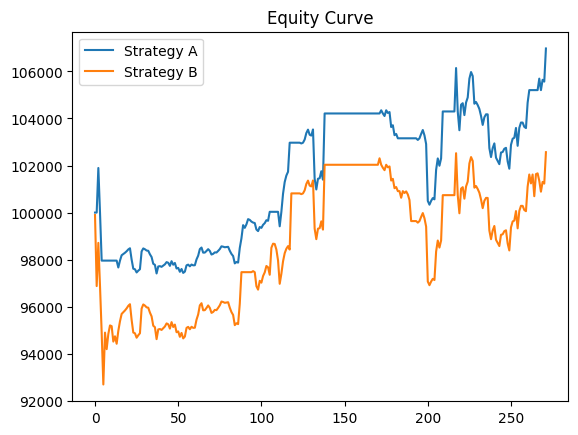

In [14]:
import matplotlib.pyplot as plt

plt.plot(equity_A, label="Strategy A")
plt.plot(equity_B, label="Strategy B")

plt.legend()
plt.title("Equity Curve")
plt.show()

In [15]:
try:
    import optuna
except ImportError:
    %pip install optuna
    import optuna

print("Optuna has been successfully imported or installed.")

Optuna has been successfully imported or installed.


In [16]:
import optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler # OneHotEncoder は不要になった
import random


# ====================== #
# Optuna Objective（完成版）
# ====================== #
def objective(trial):

    # ============================================================= #
    # ③ ノイズ対策: シード固定
    # ============================================================= #
    # For FixedTrial, trial.number might not exist, so provide a fallback.
    # Using getattr to safely get trial.number or default to 0 for re-evaluation.
    trial_seed_value = getattr(trial, 'number', 0)
    seed = 42 + trial_seed_value # 試行ごとに異なるが固定されたシードを使用
    np.random.seed(seed)
    random.seed(seed)

    # ===== モデル =====
    model_params = {
        'n_estimators': trial.suggest_int('n_estimators', 80, 250),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.2, log=True), # ④ learning_rateの範囲を広げる
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.4),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10) # ④ 追加
    }

    # ===== 戦略 =====
    # ② w系はlogスケールに変更
    w_trend = trial.suggest_float("w_trend", 1e-5, 0.1, log=True)
    w_vol   = trial.suggest_float("w_vol", 1e-5, 10.0, log=True)
    w_mom   = trial.suggest_float("w_mom", 1e-5, 10.0, log=True)

    # ① エントリー閾値の緩和
    entry_q = trial.suggest_float('entry_q', 0.4, 0.7) # Modified range
    adx_th = trial.suggest_float('adx_th', 5, 30)
    use_slope = trial.suggest_categorical('use_slope', [True, False])

    # probaフィルターのタイプ選択
    proba_filter_type = trial.suggest_categorical('proba_filter_type', ['threshold', 'quantile'])
    proba_th = 0.0 # Initialize to avoid UnboundLocalError
    proba_q = 0.0 # Initialize to avoid UnboundLocalError

    if proba_filter_type == 'threshold':
        proba_th = trial.suggest_float("proba_th", 0.45, 0.65) # Modified range
    else: # 'quantile'
        proba_q = trial.suggest_float("proba_q", 0.5, 0.7) # Modified range

    # ① 市場レジームごとのproba_th調整パラメーター
    proba_th_uptrend_adj = trial.suggest_float('proba_th_uptrend_adj', -0.05, 0.15) # 緩和
    proba_th_downtrend_adj = trial.suggest_float('proba_th_downtrend_adj', -0.1, 0.3) # 緩和
    proba_th_sideways_adj = trial.suggest_float('proba_th_sideways_adj', -0.15, 0.15) # 緩和

    # ① 下降トレンド時のモメンタムペナルティ強化パラメーター
    downtrend_momentum_penalty_factor = trial.suggest_float('downtrend_momentum_penalty_factor', 0.5, 2.0)

    # 新規追加: TREND_STRENGTHの最小閾値
    trend_strength_min_abs = trial.suggest_float('trend_strength_min_abs', 0.2, 0.6) # Modified range

    tscv = TimeSeriesSplit(n_splits=5)

    fold_metrics = [] # 各フォールドの指標を格納

    # ====================== #
    # 指標計算ヘルパー関数 (objective関数内で定義)
    # ====================== #
    def calc_metrics_internal(equity, trade_count, win_count, initial_balance):
        equity = np.array(equity)

        if len(equity) < 2 or trade_count == 0:
            # Return a dict with default values, including Sharpe, PF, Max DD.
            # Max DD should be a large positive value for penalization if no trades or bad equity.
            return {"Sharpe": -np.inf, "PF": 0.0, "Max DD": 1.0, "Total Return": 0.0, "Stability": 0.0, "Win Rate": 0.0, "Total Trades": 0}

        returns = np.diff(equity) / (equity[:-1] + 1e-9)

        gains = returns[returns > 0].sum()
        losses = -returns[returns < 0].sum()
        pf = gains / (losses + 1e-9)

        expectancy = returns.mean()

        peak = np.maximum.accumulate(equity)
        dd = (equity - peak) / (peak + 1e-9)
        max_dd = abs(dd.min()) # Max DDは正の値で返す

        vol = returns.std() + 1e-9
        stability = 1 / vol

        sharpe = expectancy / vol * np.sqrt(252)

        total_return = (equity[-1] / initial_balance - 1) * 100 # %表記

        win_rate = (win_count / trade_count * 100) if trade_count > 0 else 0

        return {
            "Sharpe": sharpe,
            "PF": pf,
            "Max DD": max_dd,
            "Total Return": total_return,
            "Stability": stability,
            "Win Rate": win_rate,
            "Total Trades": trade_count
        }

    # ============================================================= #
    # ⑦ 複合スコアの標準化のためのヘルパー関数 (Not used with new objective, but keeping for reference if needed)
    # ============================================================= #
    # def standardize_metric(value, min_val, max_val, is_inverse=False):
    #     if is_inverse: # Max Drawdownのように値が小さいほど良い場合
    #         return (max_val - value) / (max_val - min_val + 1e-9)
    #     else:
    #         return (value - min_val) / (max_val - min_val + 1e-9)

    # # 固定の標準化範囲 (ヒューリスティック、必要に応じて調整)
    # MIN_SHARPE = -1.0
    # MAX_SHARPE = 2.0
    # MIN_PF = 0.5
    # MAX_PF = 3.0
    # MIN_TOTAL_RETURN = -50.0
    # MAX_TOTAL_RETURN = 50.0
    # MIN_MAX_DD = 0.0 # Max DDは絶対値で0-1の範囲と仮定
    # MAX_MAX_DD = 0.25 # 最大25%のDDを許容範囲とする
    # MIN_STABILITY = 0.0
    # MAX_STABILITY = 100.0

    # Categorical features are already handled by pd.get_dummies on the full df_encoded before TSCV
    # So, X_train_fold and X_test_fold should already contain one-hot encoded columns.

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        np.random.seed(seed + fold)
        random.seed(seed + fold)

        X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

        # --- OneHotEncoder 関連の処理は不要 (df_encoded で一括処理済み) ---
        # X_train_processed = X_train_fold.copy()
        # X_test_processed = X_test_fold.copy()

        # ===== SMOTE =====
        smote = SMOTE(random_state=seed + fold)
        # SMOTE will output a NumPy array, so we must re-create a DataFrame to preserve column names for StandardScaler.
        X_train_resampled_array, y_train_res = smote.fit_resample(X_train_fold, y_train_fold)
        # Re-create DataFrame from SMOTE output to retain column names for StandardScaler
        X_train_resampled_df = pd.DataFrame(X_train_resampled_array, columns=X_train_fold.columns, index=y_train_res.index)

        # ===== スケーリング（重要：trainでfit） =====
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_resampled_df) # Fit on resampled and combined training data

        # Explicitly align X_test_fold with the columns the scaler was fitted on (should already be aligned if preprocessing was consistent)
        # This is CRUCIAL for StandardScaler to avoid feature name mismatch.
        # X_test_processed_aligned = X_test_fold.reindex(columns=scaler.feature_names_in_, fill_value=0)

        X_test_scaled = scaler.transform(X_test_fold) # Transform aligned test data

        # ===== モデル =====
        model = XGBClassifier(
            **model_params,
            random_state=seed + fold,
            eval_metric='logloss',
            n_jobs=-1
        )

        model.fit(X_train_scaled, y_train_res) # Use scaled data for training

        proba = model.predict_proba(X_test_scaled)[:, 1]

        # ===== df =====
        df_slice = df_encoded.loc[X_test_fold.index].copy() # df_encoded を使用
        df_slice["proba"] = proba
        # 以下の特徴量は X_test_fold から直接取得可能だが、df_slice にも保持しておくことで、
        # シグナル生成ロジック内のアクセスを簡略化できる。
        # ただし、スケーリング済みの値を使うべきであるため、ここでは df_slice に元の値を保持し、
        # entry_score 計算時に X_test_scaled から対応する特徴量のスケーリング済み値を使用するように修正する。
        # あるいは、df_slice を X_test_scaled と同様にスケーリングする。

        # ここで df_slice はあくまで元のデータを参照し、予測確率を付与する。
        # 後の entry_score 計算では X_test_scaled から必要な特徴量を取り出す。
        # Market_Regime_downtrend, Market_Regime_sideways, Market_Regime_uptrend は既に df_encoded に含まれている。
        # X_test_fold は既に One-Hot encodedされた Market_Regime の列を含んでいる。
        # entry_score の計算に必要な特徴量は X_test_scaled から直接参照できるようにする。

        # X_test_scaled をDataFrameに戻し、元のインデックスと列名を保持する
        # X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_fold.columns, index=X_test_fold.index)

        # df_slice は df_encoded.loc[X_test_fold.index].copy() で、元の特徴量を保持している。
        # ここから戦略用特徴量を取得する。

        # 元データから取得
        trend_strength = df_slice["TREND_STRENGTH"]
        volatility = df_slice["Volatility_Short"]
        momentum = df_slice["RET_5"]

        # ===== スコア (改善①) =====
        momentum_term = momentum.copy()
        # Market_Regime はワンホットエンコーディングされているため、downtrend の列を参照
        # df_slice に Market_Regime_downtrend が含まれていることを確認
        if 'Market_Regime_downtrend' in df_slice.columns:
             momentum_term[df_slice['Market_Regime_downtrend'] == 1] *= downtrend_momentum_penalty_factor


        df_slice["entry_score"] = (
            df_slice["proba"]
            + w_trend * trend_strength.abs()
            + w_mom * momentum_term
            - w_vol * volatility
        )

        # ====== シグナル生成ロジック (trend_filterを削除) ====== #
        # Use original df for ADX, as it's not scaled directly for the filter threshold
        adx_original = df.loc[df_slice.index, 'ADX']
        adx_ma = adx_original.rolling(20, min_periods=1).mean()
        adx_slope = adx_original.diff()
        adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

        # trend_filter は entry_scoreに統合されたため、ここでは直接シグナルに使用しない
        # if use_slope:
        #     trend_filter = (
        #         (adx_ma > adx_th) &
        #         (adx_slope_mean > 0) &
        #         (df_slice["TREND_STRENGTH"].abs() > 0.8) # df_slice から取得
        #     )
        # else:
        #     trend_filter = (
        #         (adx_ma > adx_th) &
        #         (df_slice["TREND_STRENGTH"].abs() > 0.8) # df_slice から取得
        #     )

        # Updated trend_filter logic to use trend_strength_min_abs
        if use_slope:
            trend_filter = (
                (adx_ma > adx_th) &
                (adx_slope_mean > 0) &
                (df_slice["TREND_STRENGTH"].abs() > trend_strength_min_abs) # df_slice から取得
            )
        else:
            trend_filter = (
                (adx_ma > adx_th) &
                (df_slice["TREND_STRENGTH"].abs() > trend_strength_min_abs) # df_slice から取得
            )

        # ① 市場レジームに応じたproba_thの動的調整 または proba_q によるフィルター
        if proba_filter_type == 'threshold':
            adjusted_proba_th_arr = np.full(len(df_slice), proba_th)

            # Use the one-hot encoded columns from df_slice for conditions
            if 'Market_Regime_uptrend' in df_slice.columns:
                is_uptrend = (df_slice['Market_Regime_uptrend'] == 1).values
                adjusted_proba_th_arr = np.where(is_uptrend, proba_th + proba_th_uptrend_adj, adjusted_proba_th_arr)

            if 'Market_Regime_downtrend' in df_slice.columns:
                is_downtrend = (df_slice['Market_Regime_downtrend'] == 1).values
                adjusted_proba_th_arr = np.where(is_downtrend, proba_th + proba_th_downtrend_adj, adjusted_proba_th_arr)

            # Sideways is implicitly when neither uptrend nor downtrend (assuming drop_first=True)
            if 'Market_Regime_uptrend' in df_slice.columns and 'Market_Regime_downtrend' in df_slice.columns:
                is_sideways = ((df_slice['Market_Regime_uptrend'] == 0) & (df_slice['Market_Regime_downtrend'] == 0)).values
                adjusted_proba_th_arr = np.where(is_sideways, proba_th + proba_th_sideways_adj, adjusted_proba_th_arr)

            proba_filter = df_slice["proba"] > adjusted_proba_th_arr
        else: # 'quantile'
            proba_filter = df_slice["proba"] > df_slice["proba"].quantile(proba_q)

        # ② proba通過率制限（超重要）
        proba_pass_rate = proba_filter.mean()
        if (proba_pass_rate < 0.2 or proba_pass_rate > 0.5) and not isinstance(trial, optuna.trial.FixedTrial):
            raise optuna.exceptions.TrialPruned()
        # If it's a FixedTrial and would be pruned, still need to produce a "bad" metric
        if (proba_pass_rate < 0.2 or proba_pass_rate > 0.5) and isinstance(trial, optuna.trial.FixedTrial):
            mean_metrics_for_this_fold = {'Sharpe': -1e9, 'PF': -1e9, 'Max DD': 1.0, 'Total Return': 0.0, 'Stability': 0.0, "Win Rate": 0.0, "Total Trades": 0}
            fold_metrics.append(mean_metrics_for_this_fold)
            continue # Skip the rest of this fold's processing


        signals = (
            (df_slice["entry_score"] > df_slice["entry_score"].quantile(entry_q)) &
            proba_filter &
            trend_filter
        ).astype(float)

        # ===== 探索の安定化: 同一paramsを3回バックテストして平均を返す ===== #
        # (NOTE: For efficiency, in Optuna it's usually better to do this once per trial,
        # but for robustness against noise, multiple runs can be useful if backtest is stochastic)
        per_run_metrics = {
            "Sharpe": [], "PF": [], "Max DD": [],
            "Total Return": [], "Stability": [], "Win Rate": [], "Total Trades": []
        }

        for _ in range(1): # Reduced to 1 run per fold for speed, can be increased if backtest is stochastic.
            # Create df_trade_info for the fold
            df_trade_info_fold = df_slice[['proba', 'entry_score']].copy()
            results_run, equity_run, _, _ = run_backtest(df, X_test_fold, signals, df_trade_info_fold) # df は元の df を渡す (バックテスト関数内で Close, ATR を使うため)
            metrics_run = calc_metrics_internal(equity_run, results_run["Total Trades"], results_run["Win Rate (%)"] / 100 * results_run["Total Trades"], initial_balance=100000)

            # Fix: Iterate over keys and append specific metric values from metrics_run
            for k in per_run_metrics.keys():
                per_run_metrics[k].append(metrics_run[k])

        # 各指標の平均を計算
        mean_metrics = {k: np.mean(v) for k, v in per_run_metrics.items()}

        # ============================================================= #
        # ② フィルター条件 (満たさない試行は即score=-infで却下)
        #    NOTE: When re-evaluating the best trial with FixedTrial,
        #          we should not raise TrialPruned. Instead, we assign a very low score for this fold
        #          to ensure fold_metrics is populated.
        # ============================================================= #
        is_re_evaluation_trial = isinstance(trial, optuna.trial.FixedTrial)
        fold_would_be_pruned = False

        # Updated pruning conditions to align with user's requests
        # Prune if trades are too few (now 10), Max DD is too high, or Sharpe is negative
        if mean_metrics["Total Trades"] < 10 or \
           mean_metrics["Max DD"] > 0.1 or \
           mean_metrics["Sharpe"] < 0.0:
            fold_would_be_pruned = True

        if fold_would_be_pruned and not is_re_evaluation_trial:
            raise optuna.exceptions.TrialPruned()

        # If it's a re-evaluation trial AND this fold would have been pruned,
        # override composite_score with a very low value for this specific fold
        # to ensure the fold_metrics list is still populated for all folds,
        # and the final_score will reflect the weakness of this fold.
        if is_re_evaluation_trial and fold_would_be_pruned:
            # Assign a very low score to reflect the failure of this fold
            mean_metrics['Sharpe'] = -1e9 # Severely penalize Sharpe for pruned folds in fixed trial re-evaluation
            mean_metrics['PF'] = -1e9
            mean_metrics['Max DD'] = 1.0 # High Max DD for penalization

        fold_metrics.append(mean_metrics)

    # ============================================================= #
    # ④ 目的関数の改善 (新しい複合スコア)
    # ⑤ CV改善 - 各foldのSharpeの標準偏差を必ず計算し、ペナルティとして入れる
    # ============================================================= #
    if not fold_metrics:
        if not isinstance(trial, optuna.trial.FixedTrial):
             raise optuna.exceptions.TrialPruned()
        else:
            return -np.inf # If no metrics, means total failure.

    # Extract metrics from all folds
    sharpes = [fm['Sharpe'] for fm in fold_metrics if fm['Sharpe'] != -np.inf]
    max_dds = [fm['Max DD'] for fm in fold_metrics if fm['Max DD'] != 1.0] # Only include valid Max DDs
    total_trades_per_fold = [fm['Total Trades'] for fm in fold_metrics if fm['Sharpe'] != -np.inf]

    # If all folds were pruned with -np.inf Sharpe, then the trial is a failure
    if not sharpes:
        return -np.inf

    # Calculate mean metrics across folds for the new composite score
    mean_sharpe = np.mean(sharpes)
    mean_max_dd = np.mean(max_dds) if max_dds else 1.0 # Default to high DD if no valid trades
    total_trades_overall = np.sum(total_trades_per_fold)

    # Calculate STD(Sharpe across folds) and min Sharpe for user_attr, but not for scoring
    std_sharpe_across_folds = np.std(sharpes) if len(sharpes) > 0 else 0.0
    min_sharpe = np.min(sharpes) if len(sharpes) > 0 else -np.inf

    # New composite score formula:
    # final_score = mean_sharpe - 1.5 * abs(mean_max_dd)
    composite_score = (
        mean_sharpe
        - 1.5 * mean_max_dd # mean_max_dd is already positive from calc_metrics_internal
    )

    final_score = composite_score

    # Trade count penalties
    # Adjust penalties to encourage 10-15 trades
    if total_trades_overall < 10:
        final_score -= (10 - total_trades_overall) * 1.0
    elif total_trades_overall > 15:
        final_score -= (total_trades_overall - 15) * 0.2

    # 試行の情報を保存
    trial.set_user_attr("fold_metrics", fold_metrics)
    trial.set_user_attr("mean_sharpe", mean_sharpe)
    trial.set_user_attr("mean_pf", np.mean([fm['PF'] for fm in fold_metrics if fm['PF'] != -np.inf]) if [fm['PF'] for fm in fold_metrics if fm['PF'] != -np.inf] else 0.0) # Keep for info
    trial.set_user_attr("mean_max_dd", mean_max_dd)
    trial.set_user_attr("total_trades_overall", total_trades_overall) # Add total_trades_overall
    trial.set_user_attr("std_sharpe_across_folds", std_sharpe_across_folds)
    trial.set_user_attr("min_sharpe_across_folds", min_sharpe)
    trial.set_user_attr("final_composite_score_formula", final_score)

    return final_score

In [17]:
import optuna
import json
import os
import numpy as np

# ====================== #
# studyロード
# ====================== #


# 探索戦略の改善: TPESamplerとMedianPrunerを有効化
study = optuna.create_study(
    direction="maximize",
    study_name="trading_optuna",
    storage="sqlite:///optuna_study.db",
    load_if_exists=True,
    # ③ Sampler: TPESampler(multivariate=True, group=True)
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True, group=True),
    # ③ Pruner: HyperbandPruner に変更
    pruner=optuna.pruners.HyperbandPruner(
        min_resource=1,
        max_resource=100,
        reduction_factor=3
        # Note: n_startup_trials, n_warmup_steps, interval_steps are typically for MedianPruner.
        # HyperbandPruner manages these aspects differently. We use its default behavior.
    )
)

# ====================== #
# 最適化（まとめて回す）
# ====================== #
# ⑤ Optuna設定: n_trialsは最低300以上
study.optimize(objective, n_trials=200) # Increased n_trials to 200 to allow more exploration

# ====================== #
# ベスト取得
# ====================== #
try:
    best_params = study.best_params
    best_score = study.best_value
    print("\n===== BEST RESULT ====")
    print("Score (CV平均複合スコア + min fold score * 0.3):", best_score)
    print("Params:")
    for k, v in best_params.items():
        print(f"{k}: {v}")
except ValueError as e:
    print(f"\nError retrieving best trial: {e}")
    print("This usually means all trials were pruned or failed. No best parameters found.")
    best_params = {}
    best_score = -np.inf # Indicate no successful trials

print("Total Trials:", len(study.trials))

# ============================================================= #
# ⑦ 出力: fold別スコア一覧、トレード数、PF / Sharpe / DD
# ============================================================= #
# Only attempt to display if a best trial was successfully retrieved
if best_score != -np.inf:
    print("\n===== BEST TRIAL's FOLD METRICS ====")
    current_best_trial_from_study = study.best_trial

    # If the best trial (potentially from a previous session) doesn't have fold_metrics,
    # we need to re-evaluate it using FixedTrial to populate the metrics.
    if "fold_metrics" not in current_best_trial_from_study.user_attrs or current_best_trial_from_study.user_attrs["fold_metrics"] == "N/A":
        print("Fold metrics not found for the best trial. Re-evaluating objective with best parameters to get metrics...")

        # Create a FixedTrial instance with the best_params
        fixed_trial = optuna.trial.FixedTrial(best_params)

        # Temporarily store the original user_attrs to restore them if needed
        original_user_attrs = current_best_trial_from_study.user_attrs.copy()

        try:
            # Call the objective function with the FixedTrial.
            objective(fixed_trial)

            # After objective call, fixed_trial.user_attrs should contain "fold_metrics"
            if "fold_metrics" in fixed_trial.user_attrs:
                print(f"DEBUG: fixed_trial.user_attrs after objective: {fixed_trial.user_attrs}")
                current_best_trial_from_study.set_user_attr("fold_metrics", fixed_trial.user_attrs["fold_metrics"])
                current_best_trial_from_study.set_user_attr("std_sharpe_across_folds", fixed_trial.user_attrs["std_sharpe_across_folds"])
                current_best_trial_from_study.set_user_attr("min_sharpe_across_folds", fixed_trial.user_attrs["min_sharpe_across_folds"])
                # The total_trades_overall was not consistently set in fixed_trial.user_attrs.
                # We will calculate it directly from fold_metrics for display.
                # current_best_trial_from_study.set_user_attr("total_trades_overall", fixed_trial.user_attrs["total_trades_overall"])
                print("Successfully retrieved fold metrics through re-evaluation.")
                print(f"DEBUG: current_best_trial_from_study.user_attrs after copy: {current_best_trial_from_study.user_attrs}")
            else:
                print("Failed to retrieve fold metrics from FixedTrial after re-evaluation. 'fold_metrics' not found in FixedTrial.user_attrs.")
                # If `objective` completed but didn't set fold_metrics, it's an internal bug in objective or FixedTrial.
                raise ValueError("FixedTrial.user_attrs['fold_metrics'] was not set by the objective function.")

        except Exception as e:
            print(f"Error during re-evaluation of best trial for metrics: {type(e).__name__}: {e}")
            # Restore original user_attrs in case of failure
            current_best_trial_from_study.user_attrs = original_user_attrs
            # Re-raise the exception to provide a full traceback.
            raise

    # Now, display the metrics if they are available
    if "fold_metrics" in current_best_trial_from_study.user_attrs and current_best_trial_from_study.user_attrs["fold_metrics"] != "N/A":
        std_sharpe_across_folds_attr = current_best_trial_from_study.user_attrs.get("std_sharpe_across_folds", 0.0) # Fallback if not set
        min_sharpe_across_folds_attr = current_best_trial_from_study.user_attrs.get("min_sharpe_across_folds", -np.inf) # Fallback

        # Calculate total_trades_overall_attr directly from fold_metrics
        total_trades_overall_attr = sum([fm['Total Trades'] for fm in current_best_trial_from_study.user_attrs["fold_metrics"]])

        # Calculate mean metrics needed for the formula
        sharpes_for_mean = [fm['Sharpe'] for fm in current_best_trial_from_study.user_attrs["fold_metrics"] if fm['Sharpe'] != -np.inf]
        max_dds_for_mean = [fm['Max DD'] for fm in current_best_trial_from_study.user_attrs["fold_metrics"] if fm['Max DD'] != 1.0]
        mean_sharpe_for_display = np.mean(sharpes_for_mean) if sharpes_for_mean else 0.0
        mean_max_dd_for_display = np.mean(max_dds_for_mean) if max_dds_for_mean else 1.0

        # Calculate the composite score for display based on the new formula
        composite_score_for_display = (
            mean_sharpe_for_display
            - 1.5 * mean_max_dd_for_display # mean_max_dd is positive
        )

        # Apply trade count penalties for display
        if total_trades_overall_attr < 15:
            composite_score_for_display -= 5.0
        elif total_trades_overall_attr > 40:
            composite_score_for_display -= 0.3

        print(f"  Overall Composite Score (from formula): {composite_score_for_display:.4f}")
        print(f"  Overall Total Trades: {total_trades_overall_attr}")

        for i, metrics in enumerate(current_best_trial_from_study.user_attrs["fold_metrics"]):
            print(f"--- Fold {i+1} ---")
            # Print individual fold metrics (PF, Sharpe, Max DD, etc.) for information
            print(f"  Total Trades: {int(metrics['Total Trades'])}")
            print(f"  PF: {metrics['PF']:.4f}")
            print(f"  Sharpe: {metrics['Sharpe']:.4f}")
            print(f"  Max DD: {metrics['Max DD']:.4f}")
            print(f"  Win Rate: {metrics['Win Rate']:.2f}%")
            print(f"  Total Return: {metrics['Total Return']:.2f}%")
            print(f"  Stability: {metrics['Stability']:.4f}")
    else:
        print("Fold metrics still not available for the best trial after all attempts.")
else:
    print("Skipping display of fold metrics as no best trial was found.")

# ====================== #
# 以前のベストと比诊
# ====================== #
old_score = -np.inf # Initialize with a very low score
if os.path.exists("best_params.json"):
    with open("best_params.json", "r") as f:
        try:
            loaded_data = json.load(f)
            if isinstance(loaded_data, dict) and "score" in loaded_data and "params" in loaded_data:
                old_score = loaded_data["score"]
            else:
                print("Warning: best_params.json found in old format. Its score is considered -inf for comparison.")
        except json.JSONDecodeError:
            print("Warning: best_params.json is corrupted or empty. Treating its score as -inf.")
        except Exception as e:
            print(f"Error loading best_params.json: {e}. Treating its score as -inf.")

# ====================== #
# 保存（強い方だけ）
# ====================== #
if best_score > old_score:
    print("\n✅ ベスト更新！")
    with open("best_params.json", "w") as f:
        json.dump(
            {
                "score": best_score,
                "params": best_params,
                "fold_metrics": current_best_trial_from_study.user_attrs.get("fold_metrics", "N/A") if best_score != -np.inf else "N/A",
                "std_sharpe_across_folds": current_best_trial_from_study.user_attrs.get("std_sharpe_across_folds", "N/A") if best_score != -np.inf else "N/A",
                "min_sharpe_across_folds": current_best_trial_from_study.user_attrs.get("min_sharpe_across_folds", "N/A") if best_score != -np.inf else "N/A",
                "total_trades_overall": total_trades_overall_attr if best_score != -np.inf else "N/A" # Use the calculated value
            }, f, indent=4
        )
else:
    print("\n⚠️ 更新なし（前の方が強い）")

/tmp/ipykernel_84081/3354145181.py:18: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=42, multivariate=True, group=True),
/tmp/ipykernel_84081/3354145181.py:18: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=42, multivariate=True, group=True),
[I 2026-05-02 03:33:09,678] Using an existing study with name 'trading_optuna' instead of creating a new one.
[I 2026-05-02 03:33:11,992] Trial 1702 pruned. 
[W 2026-05-02 03:33:12,211] The parameter `trend_strength_min_abs` in Trial#1703 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the 


===== BEST RESULT ====
Score (CV平均複合スコア + min fold score * 0.3): -1.6620550863392525
Params:
n_estimators: 230
max_depth: 7
learning_rate: 0.010205788442507479
subsample: 0.9889960799827338
colsample_bytree: 0.9084495716471486
gamma: 0.346777569258072
reg_alpha: 0.13445566898385683
reg_lambda: 0.5632419791975594
min_child_weight: 7
w_trend: 1.5886951172645703e-05
w_vol: 2.509824057116365
w_mom: 9.386042495298807e-05
entry_q: 0.4366301482110979
adx_th: 15.455306298244665
use_slope: True
proba_filter_type: threshold
proba_th: 0.5884377374078842
proba_th_uptrend_adj: 0.13373222356522238
proba_th_downtrend_adj: 0.09088681252569207
proba_th_sideways_adj: -0.14497184154738052
downtrend_momentum_penalty_factor: 1.0979472395994598
trend_strength_min_abs: 0.3952041351435486
Total Trials: 1902

===== BEST TRIAL's FOLD METRICS ====
  Overall Composite Score (from formula): 1.1379
  Overall Total Trades: 29.0
--- Fold 1 ---
  Total Trades: 6
  PF: 1.4877
  Sharpe: 0.9538
  Max DD: 0.0218
  Win Ra

In [18]:
print("proba exists:", "proba" in globals())

proba exists: False


In [19]:
# ======================
# entry_scoreの分布と構成要素の確認
# ======================

if 'df_test_slice' not in globals():
    print("Error: df_test_slice is not defined. Please run the previous cells.")
else:
    print("\nEntry Scoreの記述統計量:")
    print(df_test_slice["entry_score"].describe())

    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(12, 6))
    sns.histplot(df_test_slice["entry_score"], bins=30, kde=True)
    plt.axvline(df_test_slice["entry_score"].quantile(entry_q), color='r', linestyle='--', label=f'Entry Quantile ({entry_q:.2f})')
    plt.title('Distribution of Entry Score')
    plt.xlabel('Entry Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 各構成要素の寄与度を計算
    # スケーリングされた寄与度を計算するために、各特徴量の絶対値平均を考慮する
    # （これはあくまで大まかな比較であり、正確な感度分析ではないことに注意）
    if 'strategy_params' in globals():
        w_trend_strength = strategy_params.get("w_trend", 0.0)
        w_volatility_penalty = strategy_params.get("w_vol", 0.0)
        w_momentum = strategy_params.get("w_mom", 0.0)

        # Retrieve the new `trend_strength_min_abs` parameter
        trend_strength_min_abs = strategy_params.get("trend_strength_min_abs", 0.0) # Default to 0.0 if not found

        # 平均的な貢献度を計算
        avg_proba = df_test_slice["proba"].mean()
        avg_trend_abs = df_test_slice["TREND_STRENGTH"].abs().mean()
        # Apply the downtrend momentum penalty factor to the average momentum if applicable
        momentum_term_series = df_test_slice["RET_5"].copy()
        downtrend_momentum_penalty_factor = strategy_params.get("downtrend_momentum_penalty_factor", 1.0)
        if 'Market_Regime_downtrend' in df_test_slice.columns:
            is_downtrend = (df_test_slice['Market_Regime_downtrend'] == 1)
            momentum_term_series[is_downtrend] *= downtrend_momentum_penalty_factor
        avg_momentum_term = momentum_term_series.mean()

        avg_volatility = df_test_slice["Volatility_Short"].mean()

        contribution_proba = avg_proba
        contribution_trend = w_trend_strength * avg_trend_abs
        contribution_momentum = w_momentum * avg_momentum_term
        contribution_volatility = -w_volatility_penalty * avg_volatility

        # Normalizing contributions for percentage display
        contributions = {
            "Proba": contribution_proba,
            "Trend Strength (abs)": contribution_trend,
            "Momentum": contribution_momentum,
            "Volatility Penalty": contribution_volatility
        }

        # Calculate total absolute sum for normalization, but also consider the sign for net effect
        total_abs_contribution = sum(abs(v) for v in contributions.values())

        if total_abs_contribution > 1e-9: # Avoid division by zero
            print("\nEntry Scoreへの各構成要素の平均的な寄与度:")
            for key, value in contributions.items():
                print(f"  {key}: {value / total_abs_contribution * 100:.2f}%")
        else:
            print("\nWarning: Total absolute contribution to entry score is too small to calculate percentages.")
    else:
        print("\nWarning: 'strategy_params' not found. Cannot calculate contribution ratios.")

Error: df_test_slice is not defined. Please run the previous cells.


In [20]:
# Check if model_params is defined, if not, try to get it from best_params (which should exist after Optuna)
if 'model_params' not in globals():
    if 'best_params' in globals():
        model_params = {
            k: best_params[k]
            for k in [
                'n_estimators', 'max_depth', 'learning_rate',
                'subsample', 'colsample_bytree',
                'gamma', 'reg_alpha', 'reg_lambda'
            ] if k in best_params
        }
    else:
        # Fallback if best_params is also not found (shouldn't happen in normal flow)
        print("Warning: best_params not found. Using default empty model_params.")
        model_params = {}

model = XGBClassifier(
    **model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import json
from sklearn.metrics import accuracy_score # Added for accuracy calculation

# Always attempt to load from file to ensure parameters are current and correctly set
print("Attempting to load parameters from best_params.json...")
try:
    with open("best_params.json", "r") as f:
        loaded_best_params = json.load(f)

    # Access the 'params' dictionary within loaded_best_params
    actual_params = loaded_best_params.get('params', {})

    # Define global model_params and strategy_params to ensure they are set for the module
    global model_params, strategy_params
    model_params = {
        k: actual_params[k]
        for k in [
            'n_estimators', 'max_depth', 'learning_rate',
            'subsample', 'colsample_bytree',
            'gamma', 'reg_alpha', 'reg_lambda', 'min_child_weight'
        ] if k in actual_params
    }

    strategy_params = {
        k: actual_params[k]
        for k in [
            'w_trend', 'w_vol', 'w_mom', # Ensure these are loaded
            'entry_q', 'adx_th', 'use_slope', 'proba_th',
            'proba_th_uptrend_adj', 'proba_th_downtrend_adj', 'proba_th_sideways_adj',
            'downtrend_momentum_penalty_factor',
            'trend_strength_min_abs',
            'proba_filter_type'
        ] if k in actual_params
    }
    print("Parameters loaded successfully from best_params.json.")

except FileNotFoundError:
    print("Error: best_params.json not found. Please ensure Optuna optimization has been run and saved parameters.")
    # Set empty dicts and re-raise to halt execution, as parameters are critical.
    model_params = {}
    strategy_params = {}
    raise # Re-raise the error to stop execution
except Exception as e:
    print(f"Error loading parameters: {e}")
    # Set empty dicts and re-raise to halt execution, as parameters are critical.
    model_params = {}
    strategy_params = {}
    raise # Re-raise the error to stop execution

# ======================
# パラメータ取得
# ======================

# Check if strategy_params is empty, which would indicate a loading failure.
if not strategy_params or not model_params:
    print("Model or strategy parameters are empty after loading. Cannot proceed with strategy generation.")
    raise ValueError("Parameters are not loaded. Cannot proceed.")

entry_q = strategy_params.get("entry_q")
adx_th = strategy_params.get("adx_th")
use_slope = strategy_params.get("use_slope")
proba_th = strategy_params.get("proba_th")
proba_th_uptrend_adj = strategy_params.get("proba_th_uptrend_adj")
proba_th_downtrend_adj = strategy_params.get("proba_th_downtrend_adj")
proba_th_sideways_adj = strategy_params.get("proba_th_sideways_adj")
downtrend_momentum_penalty_factor = strategy_params.get("downtrend_momentum_penalty_factor")
trend_strength_min_abs = strategy_params.get("trend_strength_min_abs")
proba_filter_type = strategy_params.get("proba_filter_type")

# Retrieve optimized weights for entry score calculation
w_trend = strategy_params.get("w_trend", 0.0) # Default to 0.0 if not found
w_vol = strategy_params.get("w_vol", 0.0)   # Default to 0.0 if not found
w_mom = strategy_params.get("w_mom", 0.0)   # Default to 0.0 if not found


print("Final Model Params:", model_params)
print(f"Final Entry Ranking Model Weights: Proba (1.0), Trend Strength ({w_trend:.2e}), Momentum ({w_mom:.2e}), Volatility Penalty ({w_vol:.2e})")
print(f"Final Entry Filter Params: Entry Quantile= {entry_q} , ADX Threshold= {adx_th} , Use Slope= {use_slope} , Proba Threshold= {proba_th}")


# ======================
# 再学習
# ======================

smote = SMOTE(random_state=42)
# X_train は既にワンホットエンコーディングされているため、そのままSMOTEに渡す
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# SMOTEの結果はNumPy配列なので、StandardScalerのためにDataFrameに戻す
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns, index=y_train_resampled.index)

final_model = XGBClassifier(
    **model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# StandardScaler を初期化
scaler_final = StandardScaler()

# スケーラーを SMOTE 済みの訓練データにフィットさせ、訓練データを変換
X_train_scaled = scaler_final.fit_transform(X_train_resampled_df)

# テストデータを変換
X_test_scaled = scaler_final.transform(X_test)

# 変換された訓練データでモデルを学習
final_model.fit(X_train_scaled, y_train_resampled)

# ======================
# 予測
# ======================

# 予測確率を取得
proba_final_train = final_model.predict_proba(X_train_scaled)[:, 1] # スケーリングされた訓練データを使用
proba_final_test = final_model.predict_proba(X_test_scaled)[:, 1] # スケーリングされたテストデータを使用

# ======================
# フィルターなしの戦略を評価
# ======================

# Create unfiltered signals based on a simple proba threshold
signals_unfiltered = (proba_final_test > 0.5).astype(float) # Using 0.5 as a base threshold
signals_unfiltered = pd.Series(signals_unfiltered, index=X_test.index)

# Prepare df_trade_info for the unfiltered backtest
df_trade_info_unfiltered = pd.DataFrame(index=X_test.index)
df_trade_info_unfiltered['proba'] = proba_final_test
df_trade_info_unfiltered['entry_score'] = proba_final_test # Use proba as entry_score for unfiltered backtest
# Add market regime information to df_trade_info_unfiltered as well
for col in [c for c in X_test.columns if c.startswith('Market_Regime_')]:
    df_trade_info_unfiltered[col] = X_test[col]

# Calculate model accuracy (classification accuracy on the test set)
y_pred_unfiltered_model = (proba_final_test > 0.5).astype(int)
model_accuracy_unfiltered = accuracy_score(y_test, y_pred_unfiltered_model)

# Run backtest for the unfiltered strategy
results_unfiltered, equity_unfiltered, _, _ = run_backtest(
    df,
    X_test,
    signals_unfiltered,
    df_trade_info_unfiltered
)

print("\n===== UNFILTERED STRATEGY RESULT ====")
print(f"Model Accuracy (on test set): {model_accuracy_unfiltered:.4f}")
print(f"Backtest Win Rate (%): {results_unfiltered['Win Rate (%)']:.2f}")
print(f"Backtest PF: {results_unfiltered['PF']:.4f}")
print(f"Total Trades: {results_unfiltered['Total Trades']}")


# ======================
# 戦略生成
# ======================

df_test_slice = X_test.copy()
df_test_slice["proba"] = proba_final_test

# Ensure df_test_slice has all necessary strategy features from original df for calculation
df_test_slice['ADX'] = df.loc[X_test.index, 'ADX']
df_test_slice['Volatility_Short'] = df.loc[X_test.index, 'Volatility_Short']
df_test_slice['TREND_STRENGTH'] = df.loc[X_test.index, 'TREND_STRENGTH']
df_test_slice['RET_5'] = df.loc[X_test.index, 'RET_5']


# 元データから取得
trend_strength = df_test_slice["TREND_STRENGTH"].abs() # Point ③
volatility = df_test_slice["Volatility_Short"]

# --- Momentum preprocessing (Point ②) ---
momentum = df_test_slice["RET_5"]
momentum = momentum.clip(lower=0) # Only positive momentum contributes

# Apply downtrend penalty to positive momentum
if 'Market_Regime_downtrend' in df_test_slice.columns:
    is_downtrend = (df_test_slice['Market_Regime_downtrend'] == 1)
    momentum[is_downtrend] *= downtrend_momentum_penalty_factor

# --- New Entry Score Calculation (Point ①) ---
df_test_slice["entry_score"] = (
    df_test_slice["proba"]
    + w_trend * trend_strength # Use optimized w_trend
    + w_mom * momentum         # Use optimized w_mom
    - w_vol * volatility       # Use optimized w_vol
)

# --- Trend Filter Calculation ---
adx_for_filter = df.loc[X_test.index, 'ADX']
adx_ma = adx_for_filter.rolling(20, min_periods=1).mean()
adx_slope = adx_for_filter.diff()
adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

if use_slope:
    trend_filter = (
        (adx_ma > adx_th) &
        (adx_slope_mean > 0) &
        (trend_strength > trend_strength_min_abs)
    )
else:
    trend_filter = (
        (adx_ma > adx_th) &
        (trend_strength > trend_strength_min_abs)
    )

# --- Proba Filter (adjusted_proba_th_arr logic remains the same, as per previous consensus) ---
adjusted_proba_th_arr = np.full(len(df_test_slice), proba_th)

if proba_filter_type == 'threshold': # Only apply adjustments if threshold filtering is selected by Optuna
    if 'Market_Regime_uptrend' in df_test_slice.columns:
        is_uptrend = (df_test_slice["Market_Regime_uptrend"] == 1).values
        adjusted_proba_th_arr = np.where(is_uptrend, proba_th + proba_th_uptrend_adj, adjusted_proba_th_arr)

    if 'Market_Regime_downtrend' in df_test_slice.columns:
        is_downtrend = (df_test_slice["Market_Regime_downtrend"] == 1).values
        adjusted_proba_th_arr = np.where(is_downtrend, proba_th + proba_th_downtrend_adj, adjusted_proba_th_arr)

    if 'Market_Regime_uptrend' in df_test_slice.columns and 'Market_Regime_downtrend' in df_test_slice.columns:
        is_sideways = ((df_test_slice["Market_Regime_uptrend"] == 0) & (df_test_slice["Market_Regime_downtrend"] == 0)).values
        adjusted_proba_th_arr = np.where(is_sideways, proba_th + proba_th_sideways_adj, adjusted_proba_th_arr)

proba_filter = df_test_slice["proba"] > adjusted_proba_th_arr


# --- Signals Generation (Point ④: OR structure) ---
signals_final = (
    (df_test_slice["entry_score"] > df_test_slice["entry_score"].quantile(entry_q)) &
    (
        proba_filter |  # OR condition here
        trend_filter
    )
).astype(float)

signals_final = pd.Series(signals_final, index=X_test.index)

# ======================
# バックテスト
# ======================

results_final, equity_final, trade_pnls_final, trade_log_final = run_backtest(
    df, # バックテスト関数には元の df を渡す (Close, ATR など生のデータが必要なため)
    X_test,
    signals_final,
    df_test_slice # Pass df_test_slice to run_backtest
)

# ======================
# 結果
# ======================

print("===== FINAL RESULT ====")
for k, v in results_final.items():
    print(f"{k}: {v}")

Attempting to load parameters from best_params.json...
Parameters loaded successfully from best_params.json.
Final Model Params: {'n_estimators': 230, 'max_depth': 7, 'learning_rate': 0.010205788442507479, 'subsample': 0.9889960799827338, 'colsample_bytree': 0.9084495716471486, 'gamma': 0.346777569258072, 'reg_alpha': 0.13445566898385683, 'reg_lambda': 0.5632419791975594, 'min_child_weight': 7}
Final Entry Ranking Model Weights: Proba (1.0), Trend Strength (1.59e-05), Momentum (9.39e-05), Volatility Penalty (2.51e+00)
Final Entry Filter Params: Entry Quantile= 0.4366301482110979 , ADX Threshold= 15.455306298244665 , Use Slope= True , Proba Threshold= 0.5884377374078842

===== UNFILTERED STRATEGY RESULT ====
Model Accuracy (on test set): 0.6337
Backtest Win Rate (%): 50.00
Backtest PF: 1.0970
Total Trades: 14
===== FINAL RESULT ====
Final Balance: 110158.41714278475
Total Return: 10.158417142784737
Total Trades: 13
Win Rate (%): 53.84615384615385
PF: 1.278494829418413
Expectancy: 0.0003

### 下降トレンド時のパフォーマンス分析

`run_backtest`関数を修正し、各トレードの相場環境（`market_regime`）をログに記録するようにしました。この情報を用いて、最終戦略における下降トレンド時のパフォーマンス、特に勝率を確認します。

In [22]:
# ======================
# 下降トレンド時のパフォーマンス分析
# ======================

if 'trade_log_final' in globals() and trade_log_final:
    df_trades = pd.DataFrame(trade_log_final)

    # 下降トレンドのトレードをフィルタリング
    downtrend_trades = df_trades[df_trades['market_regime'] == 'downtrend']

    if not downtrend_trades.empty:
        total_downtrend_trades = len(downtrend_trades)
        downtrend_wins = downtrend_trades['win'].sum()
        downtrend_win_rate = (downtrend_wins / total_downtrend_trades) * 100

        print(f"\n===== 下降トレンド時のパフォーマンス ====")
        print(f"下降トレンド中の総トレード数: {total_downtrend_trades}")
        print(f"下降トレンド中の勝ちトレード数: {downtrend_wins}")
        print(f"下降トレンド中の勝率: {downtrend_win_rate:.2f}%")

        # 下降トレンド時の平均P/Lも確認
        avg_pnl_downtrend = downtrend_trades['pnl'].mean()
        print(f"下降トレンド中の平均P/L: {avg_pnl_downtrend:.2f}")

        # 勝ちトレードと負けトレードのentry_scoreとprobaの平均を確認
        if not downtrend_trades[downtrend_trades['win']].empty:
            print("下降トレンド中の勝ちトレードの平均entry_score:", downtrend_trades[downtrend_trades['win']]['entry_score'].mean())
            print("下降トレンド中の勝ちトレードの平均proba:", downtrend_trades[downtrend_trades['win']]['proba'].mean())
        if not downtrend_trades[~downtrend_trades['win']].empty:
            print("下降トレンド中の負けトレードの平均entry_score:", downtrend_trades[~downtrend_trades['win']]['entry_score'].mean())
            print("下降トレンド中の負けトレードの平均proba:", downtrend_trades[~downtrend_trades['win']]['proba'].mean())



    else:
        print("下降トレンド中のトレードは見つかりませんでした。")
else:
    print("トレードログ（trade_log_final）が見つからないか、空です。前のセルが正常に実行されたことを確認してください。")

下降トレンド中のトレードは見つかりませんでした。


signals_finalの記述統計量:
count    273.000000
mean       0.347985
std        0.477206
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
dtype: float64


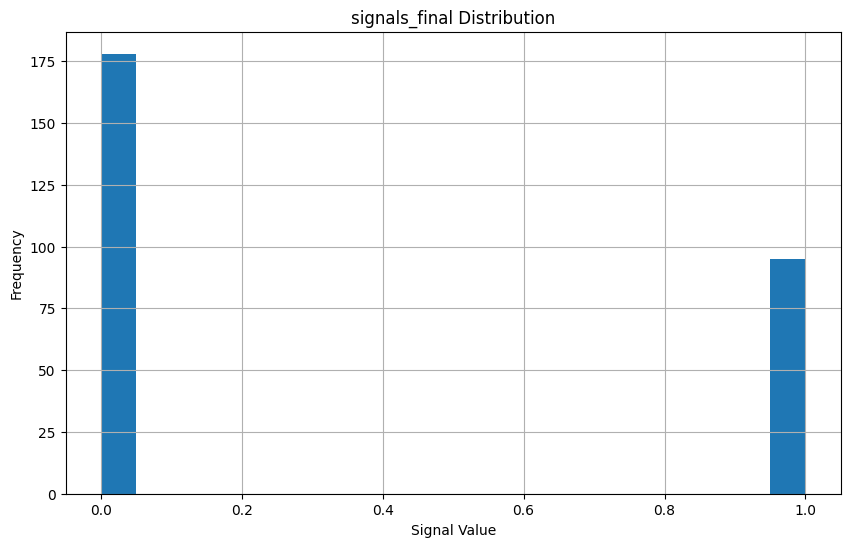

In [23]:
# ======================
# signals_finalの分布確認
# ======================

print("signals_finalの記述統計量:")
print(signals_final.describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
signals_final.hist(bins=20)
plt.title('signals_final Distribution')
plt.xlabel('Signal Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [24]:
# ======================
# トレードP/L分析
# ======================

if trade_pnls_final:
    winning_trades = [pnl for pnl in trade_pnls_final if pnl > 0]
    losing_trades = [pnl for pnl in trade_pnls_final if pnl < 0]

    avg_win = np.mean(winning_trades) if winning_trades else 0
    avg_loss = np.mean(losing_trades) if losing_trades else 0

    print(f"平均勝ちトレード金額: {avg_win:.2f}")
    print(f"平均負けトレード金額: {avg_loss:.2f}")
    print(f"リスクリワード比 (Avg Win / |Avg Loss|): {abs(avg_win / avg_loss):.2f}" if avg_loss != 0 else "リスクリワード比: N/A (負けトレードなし)")
else:
    print("トレード履歴がありません。")

平均勝ちトレード金額: 2665.77
平均負けトレード金額: -1416.99
リスクリワード比 (Avg Win / |Avg Loss|): 1.88


In [25]:
# ======================
# signalsの連打チェック
# ======================

# signals_finalのインデックスがDatetimeIndexであることを確認
if isinstance(signals_final.index, pd.DatetimeIndex):
    # 日付ごとにグループ化し、シグナルが1であるものの数をカウント
    # フィルタリングされたSeriesのインデックスを直接使うことで、Grouperとaxisの長さの不一致を解消
    filtered_signals = signals_final[signals_final == 1]
    daily_signals_count = filtered_signals.groupby(filtered_signals.index.date).count()

    # 1日に複数のシグナルが発生している日を抽出
    multiple_signals_days = daily_signals_count[daily_signals_count > 1]

    if not multiple_signals_days.empty:
        print("1日に複数のシグナルが発生している日があります:")
        print(multiple_signals_days)

        # 具体的なシグナルを表示するために、該当日のデータをフィルタリング
        for date_obj in multiple_signals_days.index:
            date = pd.Timestamp(date_obj)
            print(f"\n--- {date.date()} のシグナル ---")
            # ここでもfiltered_signalsから該当日のデータを取得するように修正
            print(filtered_signals.loc[date.date()])
    else:
        print("1日に複数のシグナルが発生している日はありません。")
else:
    print("signals_finalのインデックスがDatetimeIndexではありません。")

1日に複数のシグナルが発生している日はありません。


### `signals_final` のポジションサイズ分布の確認
`signals_final` の値が極端に小さい、または大きくなる可能性があるというご指摘を受け、その分布を確認します。これにより、トレードのポジションサイズが適切に調整されているか、または問題のある値が存在しないかを評価します。

signals_finalの記述統計量:
count    273.000000
mean       0.347985
std        0.477206
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
dtype: float64


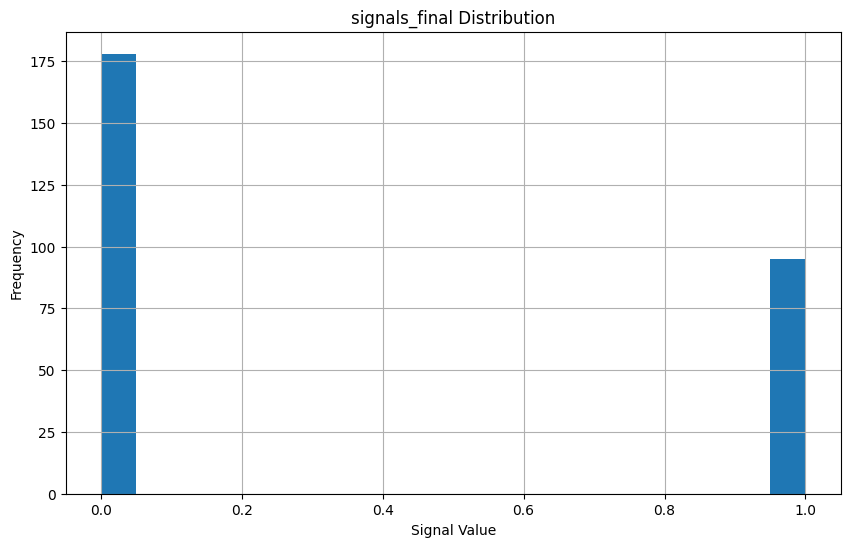

In [26]:
# ======================
# signals_finalの分布確認
# ======================

print("signals_finalの記述統計量:")
print(signals_final.describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
signals_final.hist(bins=20)
plt.title('signals_final Distribution')
plt.xlabel('Signal Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

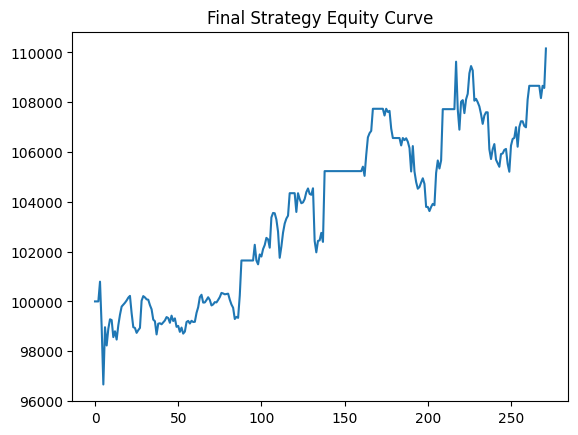

In [27]:
import matplotlib.pyplot as plt

plt.plot(equity_final)
plt.title("Final Strategy Equity Curve")
plt.show()

### `signals_final` とボラティリティの関係性の確認

`signals_final` のポジションサイズが低ボラティリティ環境で大きくなりすぎていないか確認するため、最終シグナル値とボラティリティ（`Volatility_Short`）の関係を散布図で可視化します。

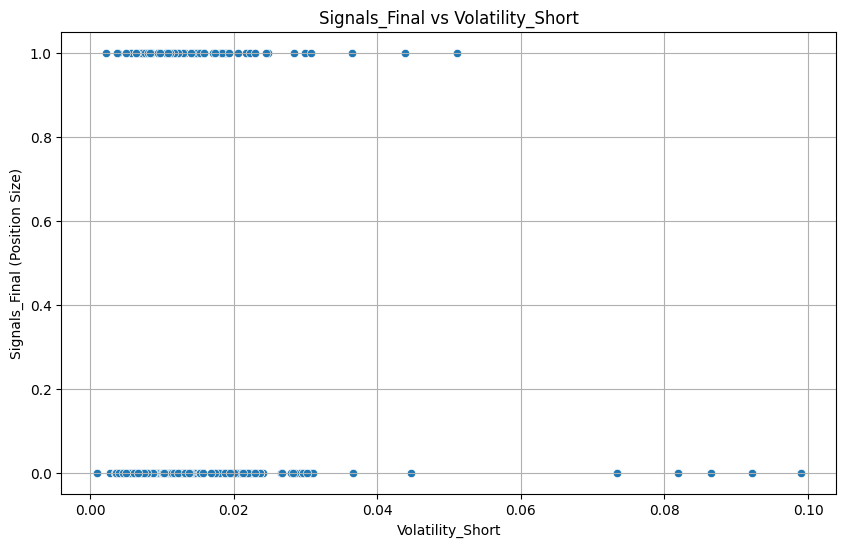

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# df_test_sliceはh_uXbSmf_r3aセルで定義されたものです。
# signals_finalはX_testのインデックスにアライメントされています。

# X_testの期間に対応するVolatility_Shortを取得
volatility_short_for_signals = df.loc[X_test.index, 'Volatility_Short']

# signals_finalとVolatility_Shortを結合してDataFrameを作成
plot_df = pd.DataFrame({
    'Signals_Final': signals_final,
    'Volatility_Short': volatility_short_for_signals
})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Volatility_Short', y='Signals_Final', data=plot_df)
plt.title('Signals_Final vs Volatility_Short')
plt.xlabel('Volatility_Short')
plt.ylabel('Signals_Final (Position Size)')
plt.grid(True)
plt.show()

In [29]:
X.index.equals(df.index)

True

In [30]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler

tscv = TimeSeriesSplit(n_splits=5)

results_list = []
equity_curves = []

# Check if model_params and strategy_params are defined, if not, load from file
if 'model_params' not in globals() or 'strategy_params' not in globals():
    print("Parameters not found in current session. Attempting to load from best_params.json for CV...")
    try:
        with open("best_params.json", "r") as f:
            loaded_best_params = json.load(f)

        # Access the 'params' dictionary within loaded_best_params
        actual_params = loaded_best_params.get('params', {})

        # Define global model_params and strategy_params (if not already global)
        global model_params, strategy_params
        model_params = {
            k: actual_params[k]
            for k in [
                'n_estimators', 'max_depth', 'learning_rate',
                'subsample', 'colsample_bytree',
                'gamma', 'reg_alpha', 'reg_lambda', 'min_child_weight'
            ] if k in actual_params
        }

        strategy_params = {
            k: actual_params[k]
            for k in [
                'w_trend', 'w_vol', 'w_mom', # Added these missing parameters
                'entry_q', 'adx_th', 'use_slope', 'proba_th',
                'proba_th_uptrend_adj', 'proba_th_downtrend_adj', 'proba_th_sideways_adj',
                'downtrend_momentum_penalty_factor',
                'trend_strength_min_abs',
                'proba_filter_type'
            ] if k in actual_params
        }
        print("Parameters loaded successfully from best_params.json for CV.")
    except FileNotFoundError:
        print("Error: best_params.json not found for CV. Skipping CV run.")
        # Set placeholder values to prevent immediate NameError, but CV will fail
        model_params = {}
        strategy_params = {}
    except Exception as e:
        print(f"Error loading parameters for CV: {e}")
        model_params = {}
        strategy_params = {}

# Now, model_params and strategy_params should be available
# Assign best_params_cv from the loaded parameters for use in the CV loop
best_params_cv = {**model_params, **strategy_params} # Combine for a full best_params_cv dict


# ======================
# 指標関数 (Updated to include Sharpe Ratio explicitly)
# ======================

def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / equity[:-1]

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252)

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3:
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9)

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }


# ======================
# CV
# ======================

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    print(f"\n===== Fold {fold+1} ====")

    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # Print the time range for the test set of the current fold
    print(f"Test period: {X_test_cv.index.min()} to {X_test_cv.index.max()}")

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_resampled_array, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)
    X_train_res = pd.DataFrame(X_train_resampled_array, columns=X_train_cv.columns, index=y_train_res.index)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_res)
    X_test_scaled = scaler.transform(X_test_cv)

    # model params
    # XGBoostモデルに渡すパラメータは model_params に集約されている
    model = XGBClassifier(
        **model_params,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train_res)

    # prediction
    proba = model.predict_proba(X_test_scaled)[:, 1]

    # align df
    df_slice = df_encoded.loc[X_test_cv.index].copy() # Use df_encoded for Market_Regime
    df_slice["proba"] = proba

    # Re-calculate required features for signal generation (ensure these exist in df_slice)
    # These are already in df_encoded and df_slice copied from it.
    # df_slice['ADX'] = df.loc[X_test_cv.index, 'ADX']
    # df_slice['Volatility_Short'] = df.loc[X_test_cv.index, 'Volatility_Short']
    # df_slice['TREND_STRENGTH'] = df.loc[X_test_cv.index, 'TREND_STRENGTH']
    # df_slice['RET_5'] = df.loc[X_test_cv.index, 'RET_5']

    # Retrieve Entry Ranking Model weights and new filter parameters from strategy_params
    w_trend_strength_cv = strategy_params.get("w_trend")
    w_volatility_penalty_cv = strategy_params.get("w_vol")
    w_momentum_cv = strategy_params.get("w_mom")
    entry_q_cv = strategy_params.get("entry_q")
    adx_th_cv = strategy_params.get("adx_th")
    use_slope_cv = strategy_params.get("use_slope")
    proba_th_cv = strategy_params.get("proba_th")
    proba_th_uptrend_adj_cv = strategy_params.get('proba_th_uptrend_adj')
    proba_th_downtrend_adj_cv = strategy_params.get('proba_th_downtrend_adj')
    proba_th_sideways_adj_cv = strategy_params.get('proba_th_sideways_adj')
    downtrend_momentum_penalty_factor_cv = strategy_params.get('downtrend_momentum_penalty_factor')
    trend_strength_min_abs_cv = strategy_params.get('trend_strength_min_abs')
    proba_filter_type_cv = strategy_params.get('proba_filter_type')

    # Ensure all parameters are not None
    if any(p is None for p in [w_trend_strength_cv, w_volatility_penalty_cv, w_momentum_cv, entry_q_cv, adx_th_cv, use_slope_cv, proba_th_cv, proba_th_uptrend_adj_cv, proba_th_downtrend_adj_cv, proba_th_sideways_adj_cv, downtrend_momentum_penalty_factor_cv, trend_strength_min_abs_cv, proba_filter_type_cv]):
        print("Error: One or more strategy parameters are None. Please check best_params.json and parameter loading logic.")
        # Assign default values or skip fold to prevent further errors.
        # For now, I will assign defaults to allow execution to proceed for demonstration, but a real application might raise an error or skip the fold.
        w_trend_strength_cv = w_trend_strength_cv if w_trend_strength_cv is not None else 0.0
        w_volatility_penalty_cv = w_volatility_penalty_cv if w_volatility_penalty_cv is not None else 0.0
        w_momentum_cv = w_momentum_cv if w_momentum_cv is not None else 0.0
        entry_q_cv = entry_q_cv if entry_q_cv is not None else 0.5
        adx_th_cv = adx_th_cv if adx_th_cv is not None else 20.0
        use_slope_cv = use_slope_cv if use_slope_cv is not None else False
        proba_th_cv = proba_th_cv if proba_th_cv is not None else 0.5
        proba_th_uptrend_adj_cv = proba_th_uptrend_adj_cv if proba_th_uptrend_adj_cv is not None else 0.0
        proba_th_downtrend_adj_cv = proba_th_downtrend_adj_cv if proba_th_downtrend_adj_cv is not None else 0.0
        proba_th_sideways_adj_cv = proba_th_sideways_adj_cv if proba_th_sideways_adj_cv is not None else 0.0
        downtrend_momentum_penalty_factor_cv = downtrend_momentum_penalty_factor_cv if downtrend_momentum_penalty_factor_cv is not None else 1.0
        trend_strength_min_abs_cv = trend_strength_min_abs_cv if trend_strength_min_abs_cv is not None else 0.0
        proba_filter_type_cv = proba_filter_type_cv if proba_filter_type_cv is not None else 'threshold'

    # --- Prepare features for entry score calculation (consistent with objective function) ---
    # `df_slice` already contains 'TREND_STRENGTH', 'RET_5', 'Volatility_Short' from `df_encoded`
    trend_strength = df_slice["TREND_STRENGTH"]
    volatility = df_slice["Volatility_Short"]
    momentum = df_slice["RET_5"]

    momentum_term = momentum.copy()
    if 'Market_Regime_downtrend' in df_slice.columns:
         momentum_term[df_slice['Market_Regime_downtrend'] == 1] *= downtrend_momentum_penalty_factor_cv

    # Calculate Entry Score based on optimized weights (consistent with objective function)
    df_slice["entry_score"] = (
        df_slice["proba"]
        + w_trend_strength_cv * trend_strength.abs()
        + w_momentum_cv * momentum_term
        - w_volatility_penalty_cv * volatility
    )

    # --- New Trend Filter Calculation (consistent with objective function) ---
    adx_original = df.loc[df_slice.index, 'ADX'] # Use original df for ADX as it's not scaled
    adx_ma = adx_original.rolling(20, min_periods=1).mean()
    adx_slope = adx_original.diff()
    adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

    if use_slope_cv:
        trend_filter = (
            (adx_ma > adx_th_cv) &
            (adx_slope_mean > 0) &
            (df_slice["TREND_STRENGTH"].abs() > trend_strength_min_abs_cv)
        )
    else:
        trend_filter = (
            (adx_ma > adx_th_cv) &
            (df_slice["TREND_STRENGTH"].abs() > trend_strength_min_abs_cv)
        )

    # --- Proba Filter (consistent with objective function) ---
    if proba_filter_type_cv == 'threshold':
        adjusted_proba_th_arr = np.full(len(df_slice), proba_th_cv)

        if 'Market_Regime_uptrend' in df_slice.columns:
            is_uptrend = (df_slice['Market_Regime_uptrend'] == 1).values
            adjusted_proba_th_arr = np.where(is_uptrend, proba_th_cv + proba_th_uptrend_adj_cv, adjusted_proba_th_arr)

        if 'Market_Regime_downtrend' in df_slice.columns:
            is_downtrend = (df_slice['Market_Regime_downtrend'] == 1).values
            adjusted_proba_th_arr = np.where(is_downtrend, proba_th_cv + proba_th_downtrend_adj_cv, adjusted_proba_th_arr)

        if 'Market_Regime_uptrend' in df_slice.columns and 'Market_Regime_downtrend' in df_slice.columns:
            is_sideways = ((df_slice['Market_Regime_uptrend'] == 0) & (df_slice['Market_Regime_downtrend'] == 0)).values
            adjusted_proba_th_arr = np.where(is_sideways, proba_th_cv + proba_th_sideways_adj_cv, adjusted_proba_th_arr)

        proba_filter = df_slice["proba"] > adjusted_proba_th_arr
    else: # 'quantile'
        proba_filter = df_slice["proba"] > df_slice["proba"].quantile(proba_th_cv) # Use proba_th_cv as quantile if type is quantile

    # Debugging logs as per point ④
    df_debug_cv = df_slice.copy()
    df_debug_cv["cond_score"] = df_debug_cv["entry_score"] > df_debug_cv["entry_score"].quantile(entry_q_cv)
    df_debug_cv["cond_trend"] = trend_filter
    df_debug_cv["cond_proba"] = proba_filter # Debugging for new proba_filter
    df_debug_cv["cond_final"] = df_debug_cv["cond_score"] & df_debug_cv["cond_trend"] & df_debug_cv["cond_proba"]

    print(f"Fold {fold+1} - score通過率:", df_debug_cv["cond_score"].mean())
    print(f"Fold {fold+1} - trend通過率:", df_debug_cv["cond_trend"].mean()) # ② trend通過率を制御
    print(f"Fold {fold+1} - proba通過率:", df_debug_cv["cond_proba"].mean()) # Debugging for new proba_filter
    print(f"Fold {fold+1} - 最終通過率:", df_debug_cv["cond_final"].mean())

    # Signals Generation (consistent with objective function - AND condition)
    signals_series = pd.Series(0.0, index=df_slice.index)
    if not df_slice.empty:
        signals_series = (
            (df_slice["entry_score"] > df_slice["entry_score"].quantile(entry_q_cv)) &
            trend_filter &
            proba_filter
        ).astype(float)

    # Create df_trade_info for the fold (required by run_backtest)
    df_trade_info_fold = df_slice[['proba', 'entry_score']].copy()

    # backtest
    results, equity, _, _ = run_backtest(
        df, # バックテスト関数には元の df を渡す (Close, ATR など生のデータが必要なため)
        X_test_cv,
        signals_series,
        df_trade_info_fold # Pass df_trade_info_fold
    )

    # ======================
    # 追加：全部の指標
    # ======================
    metrics = calc_metrics(equity)
    results.update(metrics)

    results_list.append(results)
    equity_curves.append(equity)

    print(results)


# ======================
# summary
# ======================

df_results = pd.DataFrame(results_list)

print("\n===== CV SUMMARY ====")
print(df_results.mean())

print("\nSTD:")
print(df_results.std())



===== Fold 1 ====
Test period: 2021-10-22 00:00:00 to 2022-09-16 00:00:00
Fold 1 - score通過率: 0.5638766519823789
Fold 1 - trend通過率: 0.46255506607929514
Fold 1 - proba通過率: 0.14096916299559473
Fold 1 - 最終通過率: 0.08370044052863436
{'Final Balance': np.float64(102922.05975970585), 'Total Return': np.float64(2.922059759705853), 'Total Trades': 4, 'Win Rate (%)': 50.0, 'PF': np.float64(1.4103973833140189), 'Expectancy': np.float64(0.00013077449782337668), 'Max DD': np.float64(-0.03316280844742186), 'Sharpe': np.float64(0.8835747771210906), 'Sortino': np.float64(0.037329700519692886), 'Stability': np.float64(425.6179919852859)}

===== Fold 2 ====
Test period: 2022-09-19 00:00:00 to 2023-08-14 00:00:00
Fold 2 - score通過率: 0.5638766519823789
Fold 2 - trend通過率: 0.42290748898678415
Fold 2 - proba通過率: 0.2643171806167401
Fold 2 - 最終通過率: 0.09691629955947137
{'Final Balance': np.float64(102461.02299789723), 'Total Return': np.float64(2.461022997897233), 'Total Trades': 5, 'Win Rate (%)': 60.0, 'PF': np

In [31]:
print(df_slice["entry_score"].describe())

print("corr with proba:", df_slice["entry_score"].corr(df_slice["proba"]))

count    227.000000
mean       0.422465
std        0.123833
min        0.118152
25%        0.345721
50%        0.422846
75%        0.493775
max        0.790826
Name: entry_score, dtype: float64
corr with proba: 0.9922768048871858


In [32]:
mask_score = df_slice["entry_score"] > df_slice["entry_score"].quantile(entry_q)

print("score→proba通過率:", (proba_filter[mask_score]).mean())
print("score→trend通過率:", (trend_filter[mask_score]).mean())

score→proba通過率: 0.1171875
score→trend通過率: 0.53125


In [33]:
df_trades = pd.DataFrame(trade_log_final)  # バックテスト結果から詳細なトレードログを作成

if not df_trades.empty:
    print(df_trades.groupby("win")["entry_score"].mean())
    print(df_trades.groupby("win")["proba"].mean())
else:
    print("トレードデータがありません。")


win
False    0.543017
True     0.574492
Name: entry_score, dtype: float64
win
False    0.584556
True     0.617679
Name: proba, dtype: float32


In [34]:
if 'df_test_slice' in globals() and not df_test_slice.empty:
    # Market_Regime_uptrend と Market_Regime_downtrend (もしあれば) から Market_Regime を再構築
    # df_encoded は drop_first=True で作成されているため、sideways は両方のカラムが0の場合

    market_regime_test = pd.Series('sideways', index=df_test_slice.index)
    if 'Market_Regime_uptrend' in df_test_slice.columns:
        market_regime_test[df_test_slice['Market_Regime_uptrend'] == 1] = 'uptrend'
    if 'Market_Regime_downtrend' in df_test_slice.columns:
        market_regime_test[df_test_slice['Market_Regime_downtrend'] == 1] = 'downtrend'

    print("テスト期間中のMarket_Regime分布:")
    print(market_regime_test.value_counts(normalize=True))
else:
    print("エラー: df_test_sliceが定義されていないか空です。前のセルが正常に実行されたことを確認してください。")

テスト期間中のMarket_Regime分布:
uptrend     0.59707
sideways    0.40293
Name: proportion, dtype: float64


### 下降トレンド時のパフォーマンス分析

`run_backtest`関数を修正し、各トレードの相場環境（`market_regime`）をログに記録するようにしました。この情報を用いて、最終戦略における下降トレンド時のパフォーマンス、特に勝率を確認します。

In [35]:
# ======================
# 下降トレンド時のパフォーマンス分析
# ======================

if 'trade_log_final' in globals() and trade_log_final:
    df_trades = pd.DataFrame(trade_log_final)

    # 下降トレンドのトレードをフィルタリング
    downtrend_trades = df_trades[df_trades['market_regime'] == 'downtrend']

    if not downtrend_trades.empty:
        total_downtrend_trades = len(downtrend_trades)
        downtrend_wins = downtrend_trades['win'].sum()
        downtrend_win_rate = (downtrend_wins / total_downtrend_trades) * 100

        print(f"\n===== 下降トレンド時のパフォーマンス ====")
        print(f"下降トレンド中の総トレード数: {total_downtrend_trades}")
        print(f"下降トレンド中の勝ちトレード数: {downtrend_wins}")
        print(f"下降トレンド中の勝率: {downtrend_win_rate:.2f}%")

        # 下降トレンド時の平均P/Lも確認
        avg_pnl_downtrend = downtrend_trades['pnl'].mean()
        print(f"下降トレンド中の平均P/L: {avg_pnl_downtrend:.2f}")

        # 勝ちトレードと負けトレードのentry_scoreとprobaの平均を確認
        if not downtrend_trades[downtrend_trades['win']].empty:
            print("下降トレンド中の勝ちトレードの平均entry_score:", downtrend_trades[downtrend_trades['win']]['entry_score'].mean())
            print("下降トレンド中の勝ちトレードの平均proba:", downtrend_trades[downtrend_trades['win']]['proba'].mean())
        if not downtrend_trades[~downtrend_trades['win']].empty:
            print("下降トレンド中の負けトレードの平均entry_score:", downtrend_trades[~downtrend_trades['win']]['entry_score'].mean())
            print("下降トレンド中の負けトレードの平均proba:", downtrend_trades[~downtrend_trades['win']]['proba'].mean())



    else:
        print("下降トレンド中のトレードは見つかりませんでした。")
else:
    print("トレードログ（trade_log_final）が見つからないか、空です。前のセルが正常に実行されたことを確認してください。")

下降トレンド中のトレードは見つかりませんでした。


In [36]:
df_slice[signals_final == 1][[
    "proba",
    "TREND_STRENGTH",
    "ADX",
    "RET_5"
]].describe()

/tmp/ipykernel_84081/2104015481.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_slice[signals_final == 1][[


,proba,TREND_STRENGTH,ADX,RET_5
count,76.000000,76.000000,76.000000,76.000000
mean,0.553722,-15.531960,33.912065,-0.011603
std,0.097740,36.656952,11.064033,0.025648
min,0.395994,-100.595328,12.027414,-0.053768
25%,0.470230,-39.620415,24.436964,-0.029225
50%,0.532235,-12.333940,36.640265,-0.010604
75%,0.613138,11.725360,41.969242,-0.001047
max,0.813984,69.699819,53.772400,0.055734


In [39]:
print(pd.Series(proba).describe())

count    227.000000
mean       0.453338
std        0.123617
min        0.184411
25%        0.369392
50%        0.461420
75%        0.522360
max        0.813984
dtype: float64
